In [41]:
import librosa
import numpy as np

## Extract features

In [42]:
import json

def create_beat_labels(json_path, salami_id, beat_times):
    """
    Create integer beat-level labels for a given song in the SALAMI dataset.
    Useful for training with PyTorch's CrossEntropyLoss.

    Parameters
    ----------
    json_path : str
        Path to the combined_data.json file.
    salami_id : int
        The song ID (e.g., 3).
    beat_times : list of float
        Beat times in seconds.

    Returns
    -------
    beat_labels_idx : list of int
        Label indices for each beat.
    label_to_idx : dict
        Mapping from string labels -> integer indices.
    idx_to_label : dict
        Mapping from integer indices -> string labels.
    """
    # Load data
    with open(json_path, "r") as f:
        data = json.load(f)
    song_data = data[str(salami_id)]
    annotations = song_data["annotations"]

    # Collect all possible section labels in this song
    all_labels = sorted(set(ann["section_label"] for ann in annotations))
    label_to_idx = {lab: i for i, lab in enumerate(all_labels)}
    idx_to_label = {i: lab for lab, i in label_to_idx.items()}

    # Build segments (start, end, label)
    segments = []
    for ann in annotations:
        start = float(ann["start_time"])
        end = float(ann["end_time"]) if ann["end_time"] else float("inf")
        label = ann["section_label"]
        segments.append((start, end, label))

    # Assign each beat
    beat_labels_idx = []
    for bt in beat_times:
        bt = float(bt)
        label = None
        for (start, end, sec_lab) in segments:
            if start <= bt < end:
                label = sec_lab
                break
        if label is None:
            label = "Unknown"
            if label not in label_to_idx:
                new_idx = len(label_to_idx)
                label_to_idx[label] = new_idx
                idx_to_label[new_idx] = label
        beat_labels_idx.append(label_to_idx[label])

    return beat_labels_idx, label_to_idx, idx_to_label


In [50]:
# Load audio file (mono) at 8 kHz sample rate
# How Beautiful you are is SALAMI_id: 10
y, sr = librosa.load("../music-files/mp3_files/The Cure - How Beautiful You Are.mp3", sr=8000)

# Compute onset strength envelope and tempo with beat tracking
tempo, beat_frames = librosa.beat.beat_track(y=y, sr=sr)
beat_times = librosa.frames_to_time(beat_frames, sr=sr)

# Build beat labels for SALAMI_id = 10
beat_labels, label_to_idx, idx_to_label = create_beat_labels("../spectrogram-generation/SALAMI-data/combined_data.json", salami_id=10, beat_times=beat_times)


print(f"Estimated tempo: {tempo} BPM")
print(f"Beat timestamps (s): {beat_times[:10]} ...")
print(list(zip(beat_times[:10], beat_labels[:10])))
print(len(label_to_idx))

Estimated tempo: [72.11538462] BPM
Beat timestamps (s): [0.32  1.024 1.856 2.688 3.52  4.288 5.12  5.952 6.784 7.616] ...
[(np.float64(0.32), 0), (np.float64(1.024), 0), (np.float64(1.856), 0), (np.float64(2.688), 0), (np.float64(3.52), 0), (np.float64(4.288), 0), (np.float64(5.12), 0), (np.float64(5.952), 0), (np.float64(6.784), 0), (np.float64(7.616), 0)]
13


-----
The actual BPM is 145, so this is close enough

## Feature Engineering:

In [44]:
from librosa import feature, note_to_hz, cqt

## Precompute the whole song's chroma and onset envelope (safe for 8kHz)
chroma_full = feature.chroma_cqt(
    y=y,
    sr=sr,
    hop_length=512,
    fmin=note_to_hz('C1'),   # ~32.7 Hz
    n_octaves=6,             # cap so max freq < Nyquist (≈2093 Hz)
    n_chroma=12,
    bins_per_octave=36       # 3 bins per semitone (default, high resolution)
)

onset_env_full = librosa.onset.onset_strength(y=y, sr=sr)

beat_features = []

for i in range(len(beat_times) - 1):
    start, end = beat_times[i], beat_times[i+1]
    segment = y[int(start * sr): int(end * sr)]

    # Tonal features
    chroma_seg = feature.chroma_cqt(
        y=segment, sr=sr,
        hop_length=512,
        fmin=note_to_hz('C1'),
        n_octaves=6,
        n_chroma=12,
        bins_per_octave=36
    )
    tonnetz = feature.tonnetz(chroma=chroma_seg, sr=sr)

    # Chroma Energy Normalized Statistics
    cens = feature.chroma_cens(
        y=segment, sr=sr,
        hop_length=512,
        fmin=note_to_hz('C1'),
        n_octaves=6,
        n_chroma=12,
        bins_per_octave=36
    )

    # Rhythmic feature: tempogram
    onset_env_seg = librosa.onset.onset_strength(y=segment, sr=sr)
    tempogram = feature.tempogram(onset_envelope=onset_env_seg, sr=sr)

    # Spectral features: CQT (restrict bins to stay < Nyquist)
    # 72 bins @ 12 bins/octave = 6 octaves (safe, ~2093 Hz max)
    C = np.abs(cqt(y=segment, sr=sr, n_bins=72, bins_per_octave=12, fmin=note_to_hz('C1')))
    cqt_mean = C.mean(axis=1)

    # MFCC
    mfcc = feature.mfcc(y=segment, sr=sr, n_mfcc=13)

    # Summarize per beat
    tonnetz_mean = tonnetz.mean(axis=1)
    cens_mean = cens.mean(axis=1)
    tempogram_mean = tempogram.mean(axis=1)
    mfcc_mean = mfcc.mean(axis=1)

    # Combine features
    feature_vec = np.concatenate([tonnetz_mean, cens_mean, tempogram_mean, cqt_mean, mfcc_mean])
    beat_features.append(feature_vec)

/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=352
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=176
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=176
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=416
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=512 is too large for input signal of length=208
  warnings.warn(
/opt/homebrew/Caskroom/miniconda/base/lib/python3.12/site-packages/librosa/core/spectrum.py:266

## Visualization of Beat Features

In [38]:
import numpy as np
import librosa
import matplotlib.pyplot as plt

def resize_block(X, target_height, target_width):
    """Resize feature block to fixed height and width."""
    X = librosa.util.fix_length(X, size=target_width, axis=1)   # fix width (frames)
    if X.shape[0] != target_height:
        X = librosa.resample(X, orig_sr=X.shape[0], target_sr=target_height, axis=0)
    return X

def build_beat_image(segment, sr=8000, hop_length=512, height_per_block=64, width=32):
    """Build one beat slice with equalized block sizes."""
    # Compute features
    mfcc = librosa.feature.mfcc(y=segment, sr=sr, n_mfcc=13, hop_length=hop_length)
    chroma = librosa.feature.chroma_cqt(y=segment, sr=sr, hop_length=hop_length, n_octaves=6)
    onset_env = librosa.onset.onset_strength(y=segment, sr=sr, hop_length=hop_length)
    tempogram = librosa.feature.tempogram(onset_envelope=onset_env, sr=sr, hop_length=hop_length)
    
    # Resize each block to same height/width
    mfcc = resize_block(mfcc, height_per_block, width)
    chroma = resize_block(chroma, height_per_block, width)
    tempogram = resize_block(tempogram, height_per_block, width)

    # Normalize
    def norm(X): return (X - X.min()) / (X.max() - X.min() + 1e-8)
    
    return np.vstack([norm(mfcc), norm(chroma), norm(tempogram)])

def visualize_feature_fusion_full(y, sr, beat_times, beat_idx, width=32, height_per_block=64):
    """Visualize beat feature fusion with equalized sizes (like paper figure)."""
    beats = [beat_idx-2, beat_idx-1, beat_idx, beat_idx+1]
    beat_imgs = []
    for i in beats:
        start, end = int(beat_times[i]*sr), int(beat_times[i+1]*sr)
        seg = y[start:end]
        img = build_beat_image(seg, sr=sr, height_per_block=height_per_block, width=width)
        beat_imgs.append(img)

    fused_img = np.concatenate(beat_imgs, axis=1)

    plt.figure(figsize=(8, 6))
    plt.imshow(fused_img, aspect='auto', origin='lower', cmap='magma')
    plt.colorbar(label='Normalized Feature Value')
    plt.xticks([width*k + width//2 for k in range(4)],
               [f"Beat {b}" for b in beats])
    plt.ylabel("Feature Dimension (equal blocks)")
    plt.title("Beat Feature Fusion (Equalized Spectrogram-like View)")
    plt.show()


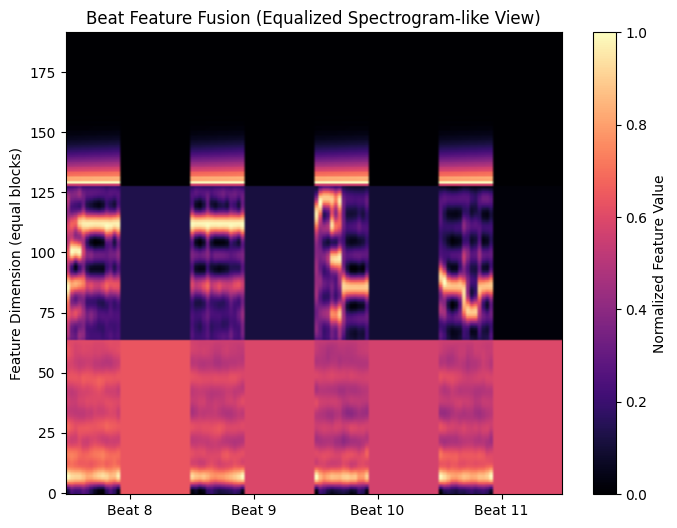

In [45]:
visualize_feature_fusion_full(y, sr, beat_times, beat_idx=10)

## Fusing Beat features

In [47]:
fused_beat_features = []
fused_labels = []  # corresponding labels for center beat i

context = 2  # number of past beats to include
for i in range(len(beat_features)):
    if i < context or i >= len(beat_features) - 1: 
        # skip first two and last beat (or handle by padding if desired)
        continue
    # Stack feature vectors for beats i-2, i-1, i, i+1 as columns
    context_matrix = np.stack([
        beat_features[i-2], 
        beat_features[i-1], 
        beat_features[i], 
        beat_features[i+1]
    ], axis=1)  # shape: (feature_dim, 4)
    fused_beat_features.append(context_matrix)
    fused_labels.append(beat_labels[i])  # the true label of beat i

## ResNet-34

In [51]:
import torch
import torch.nn as nn

# Define the basic residual block for ResNet-34 (two 3x3 conv layers + skip connection)
class BasicBlock(nn.Module):
    expansion = 1  # no expansion in channels for ResNet-34 basic blocks
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        # First conv layer in the block
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, 
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        # Second conv layer in the block
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, 
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        # downsample is an optional layer to match dimensions (used when stride != 1 or channels differ)
        self.downsample = downsample

    def forward(self, x):
        identity = x  # save input for the skip connection
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        # If there's a downsample layer (to match dimensions), apply it to the identity
        if self.downsample is not None:
            identity = self.downsample(x)
        # Add the original input (identity) to the output of the convolutions
        out += identity  
        out = self.relu(out)  # final ReLU after adding the residual
        return out

# ResNet-34 model definition
class ResNet34(nn.Module):
    def __init__(self, num_classes, in_channels=1):
        super(ResNet34, self).__init__()
        # Initial convolutional layer (7x7 kernel, stride 2) with BatchNorm and ReLU
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.relu  = nn.ReLU(inplace=True)
        # Max pooling to reduce spatial size
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        # Four main layers of ResNet-34:
        # Layer1: 64->64 channels, 3 basic blocks, stride 1
        self.layer1 = self._make_layer(64, 64, blocks=3, stride=1)
        # Layer2: 64->128 channels, 4 basic blocks, first block with stride 2 (downsample spatial size)
        self.layer2 = self._make_layer(64, 128, blocks=4, stride=2)
        # Layer3: 128->256 channels, 6 basic blocks, first block with stride 2
        self.layer3 = self._make_layer(128, 256, blocks=6, stride=2)
        # Layer4: 256->512 channels, 3 basic blocks, first block with stride 2
        self.layer4 = self._make_layer(256, 512, blocks=3, stride=2)
        # After convolutions, apply global average pooling and a fully-connected layer for classification
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512 * BasicBlock.expansion, num_classes)
    
    def _make_layer(self, in_channels, out_channels, blocks, stride):
        """Construct one layer of the ResNet (a sequence of residual blocks)."""
        # If we need to downsample (for stride 2 or channel mismatch), prepare a downsample layer
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        layers = []
        # First block of the layer: may use stride 2 and the downsample
        layers.append(BasicBlock(in_channels, out_channels, stride=stride, downsample=downsample))
        # Remaining blocks (stride=1, in_channels == out_channels)
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # Initial convolution + BN + ReLU + MaxPool
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        # Pass through each ResNet layer (each has multiple residual blocks)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        # Global average pool to get 1x1 spatial output
        x = self.avgpool(x)       # shape: (batch, 512, 1, 1)
        x = x.view(x.size(0), -1) # flatten to (batch, 512)
        x = self.fc(x)            # final linear layer for classification
        return x

# Instantiate the model (13 classes for this example)
# ^ WE NEED TO FIX THE NUMBER OF CLASSES GLOBALLY FOR ALL INPUTS
num_classes = 13
model = ResNet34(num_classes=num_classes, in_channels=1)

## Training Loop

In [72]:
import torch

device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model.to(device)

ResNet34(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, ker

In [73]:
print("using mps" if torch.backends.mps.is_available() else "using cpu")

using mps


In [74]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()             # loss function for multi-class classification
optimizer = optim.Adam(model.parameters(), lr=0.001)  # choose optimizer (Adam here)

In [105]:
num_classes = len(label_to_idx)
model = ResNet34(num_classes=num_classes, in_channels=1).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 30
for epoch in range(1, num_epochs+1):
    model.train()
    running_loss = 0.0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch} Batch {batch_idx}, Loss: {loss.item():.4f}")


Epoch 1 Batch 0, Loss: 2.6288
Epoch 1 Batch 10, Loss: 1.6386
Epoch 2 Batch 0, Loss: 1.6251
Epoch 2 Batch 10, Loss: 1.5057
Epoch 3 Batch 0, Loss: 1.3778
Epoch 3 Batch 10, Loss: 1.6025
Epoch 4 Batch 0, Loss: 1.4126
Epoch 4 Batch 10, Loss: 1.1746
Epoch 5 Batch 0, Loss: 1.2390
Epoch 5 Batch 10, Loss: 1.1665
Epoch 6 Batch 0, Loss: 1.2283
Epoch 6 Batch 10, Loss: 1.1044
Epoch 7 Batch 0, Loss: 0.9589
Epoch 7 Batch 10, Loss: 0.8654
Epoch 8 Batch 0, Loss: 1.1029
Epoch 8 Batch 10, Loss: 0.9683
Epoch 9 Batch 0, Loss: 0.8931
Epoch 9 Batch 10, Loss: 1.2582
Epoch 10 Batch 0, Loss: 1.2782
Epoch 10 Batch 10, Loss: 1.0265
Epoch 11 Batch 0, Loss: 0.8784
Epoch 11 Batch 10, Loss: 0.8128
Epoch 12 Batch 0, Loss: 0.7069
Epoch 12 Batch 10, Loss: 0.7468
Epoch 13 Batch 0, Loss: 0.9615
Epoch 13 Batch 10, Loss: 0.9767
Epoch 14 Batch 0, Loss: 1.1404
Epoch 14 Batch 10, Loss: 0.8477
Epoch 15 Batch 0, Loss: 1.0101
Epoch 15 Batch 10, Loss: 0.7029
Epoch 16 Batch 0, Loss: 0.8969
Epoch 16 Batch 10, Loss: 0.6479
Epoch 17 B

## Evaluation

In [106]:
preds = []
model.eval()
with torch.no_grad():
    for inputs, _ in train_loader:        # labels can be dummy here if not needed
        inputs = inputs.to(device)      # move batch to MPS
        outputs = model(inputs)         # forward pass
        batch_preds = outputs.argmax(dim=1).cpu().numpy()
        preds.extend(batch_preds)

In [107]:
def build_segments(pred_labels, beat_times, idx_to_label):
    """
    Convert beat-level predictions into segment annotations.
    """
    segments = []
    current_label = pred_labels[0]
    seg_start = beat_times[0]   # start at first beat
    for i in range(1, len(pred_labels)):
        if pred_labels[i] != current_label:
            seg_end = beat_times[i]
            segments.append({
                "start_time": f"{seg_start:.9f}",
                "end_time": f"{seg_end:.9f}",
                "section_label": idx_to_label[current_label],
                "section": idx_to_label[current_label]
            })
            seg_start = seg_end
            current_label = pred_labels[i]

    # Add final segment
    segments.append({
        "start_time": f"{seg_start:.9f}",
        "end_time": f"{beat_times[-1]:.9f}",
        "section_label": idx_to_label[current_label],
        "section": idx_to_label[current_label]
    })
    return segments


### Prediction Smoothing

In [113]:
from scipy.stats import mode

def smooth_predictions(pred_labels, window_size=6):
    """
    Smooth beat-level predictions using a majority vote in a sliding window.
    
    Parameters
    ----------
    pred_labels : list[int]
        Sequence of predicted class indices.
    window_size : int
        Number of beats in the smoothing window (default = 6).
    
    Returns
    -------
    smoothed : list[int]
        Smoothed label sequence.
    """
    smoothed = []
    half_w = window_size // 2
    for i in range(len(pred_labels)):
        start = max(0, i - half_w)
        end = min(len(pred_labels), i + half_w + 1)
        window = pred_labels[start:end]
        # majority vote
        smoothed.append(int(mode(window, keepdims=True)[0][0]))
    return smoothed

In [114]:
# Smooth predictions before visualization
pred_labels_smoothed = smooth_predictions(preds, window_size=6)

In [119]:
gt_segments = build_segments(beat_labels, beat_times, idx_to_label)
pred_segments = build_segments(pred_labels_smoothed, beat_times, idx_to_label)

In [120]:
import pandas as pd

def compare_segments(gt_segments, pred_segments):
    # Convert to DataFrames for side-by-side
    df_gt = pd.DataFrame(gt_segments)[["start_time", "end_time", "section_label"]]
    df_pred = pd.DataFrame(pred_segments)[["start_time", "end_time", "section_label"]]
    df_gt.columns = ["GT_start", "GT_end", "GT_label"]
    df_pred.columns = ["Pred_start", "Pred_end", "Pred_label"]
    return pd.concat([df_gt, df_pred], axis=1)

comparison_df = compare_segments(gt_segments, pred_segments)
print(comparison_df)

        GT_start        GT_end GT_label     Pred_start       Pred_end  \
0    0.320000000  14.208000000        A    0.320000000    1.856000000   
1   14.208000000  27.392000000       a'    1.856000000    5.952000000   
2   27.392000000  40.576000000        b    5.952000000    6.784000000   
3   40.576000000  53.760000000       b'    6.784000000   15.872000000   
4   53.760000000  67.008000000        B   15.872000000   17.472000000   
..           ...           ...      ...            ...            ...   
74           NaN           NaN      NaN  281.472000000  282.240000000   
75           NaN           NaN      NaN  282.240000000  286.400000000   
76           NaN           NaN      NaN  286.400000000  292.160000000   
77           NaN           NaN      NaN  292.160000000  298.752000000   
78           NaN           NaN      NaN  298.752000000  302.080000000   

   Pred_label  
0           D  
1           B  
2           c  
3          b'  
4           D  
..        ...  
74         

### Visualize

In [121]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def visualize_comparison(beat_times, gt_labels, pred_labels, idx_to_label):
    """
    Show ground truth vs predicted structure with legend.
    """
    n_beats = len(beat_times) - 1

    # Collect all labels
    unique_labels = sorted(set(gt_labels) | set(pred_labels))
    label_to_color = {lab: i for i, lab in enumerate(unique_labels)}

    # Map labels to color indices
    gt_colors = [label_to_color[l] for l in gt_labels]
    pred_colors = [label_to_color[l] for l in pred_labels]

    fig, ax = plt.subplots(2, 1, figsize=(14, 4), sharex=True)

    ax[0].imshow(np.array(gt_colors)[None, :], aspect="auto", cmap="tab20")
    ax[0].set_yticks([0]); ax[0].set_yticklabels(["Ground Truth"])
    ax[0].set_ylabel("")

    ax[1].imshow(np.array(pred_colors)[None, :], aspect="auto", cmap="tab20")
    ax[1].set_yticks([0]); ax[1].set_yticklabels(["Prediction"])
    ax[1].set_ylabel("")

    ax[1].set_xticks(np.linspace(0, n_beats, 10))
    ax[1].set_xticklabels([f"{beat_times[int(i)]:.1f}s" for i in np.linspace(0, n_beats-1, 10)])
    ax[1].set_xlabel("Time (s)")

    # Add legend
    handles = [mpatches.Patch(color=plt.cm.tab20(label_to_color[lab]/len(unique_labels)), label=lab)
               for lab in unique_labels]
    fig.legend(handles=handles, loc="upper center", ncol=min(6, len(unique_labels)))

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Visualizing annotations for side by side comparison to ensure correctness of Ground Truth

In [131]:
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def visualize_annotations(json_path, salami_id, label_key="full_label"):
    """
    Visualize SALAMI ground truth annotations directly from JSON,
    with legend placed nicely below the plot (no overlap).
    """
    with open(json_path, "r") as f:
        data = json.load(f)
    song_data = data[str(salami_id)]
    annotations = song_data["annotations"]

    starts, ends, labels = [], [], []
    for ann in annotations:
        start = float(ann["start_time"])
        end = float(ann["end_time"]) if ann["end_time"] else None
        if not end:  # skip open-ended final marker
            continue
        label = ann[label_key]
        starts.append(start)
        ends.append(end)
        labels.append(label)

    unique_labels = sorted(set(labels))
    label_to_color = {lab: i for i, lab in enumerate(unique_labels)}

    # Increase figure height so there's room for legend
    fig, ax = plt.subplots(figsize=(14, 4))  # taller than before

    # Plot the segments
    for s, e, lab in zip(starts, ends, labels):
        ax.barh(0, e - s, left=s,
                color=plt.cm.tab20(label_to_color[lab] / len(unique_labels)),
                edgecolor="black")

    ax.set_yticks([0])
    ax.set_yticklabels(["Ground Truth"])
    ax.set_xlabel("Time (s)")
    ax.set_xlim([0, max(ends)])

    # Legend patches
    handles = [
        mpatches.Patch(
            color=plt.cm.tab20(label_to_color[lab] / len(unique_labels)), 
            label=lab
        )
        for lab in unique_labels
    ]

    # Put legend under plot without shrinking plot
    fig.legend(
        handles=handles, 
        loc="upper center", 
        bbox_to_anchor=(0.5, -0.1),   # below axes
        ncol=6
    )

    plt.tight_layout()
    plt.show()


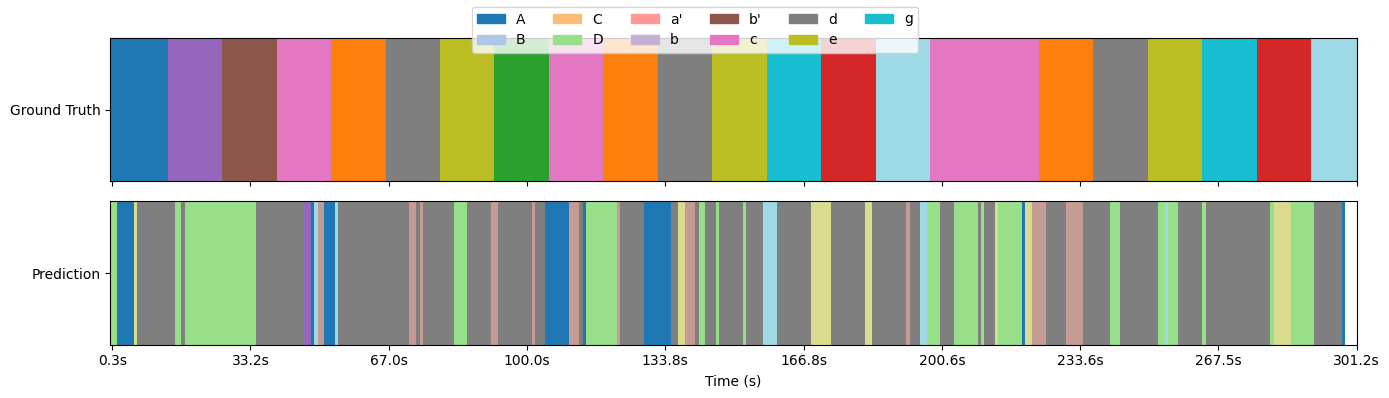

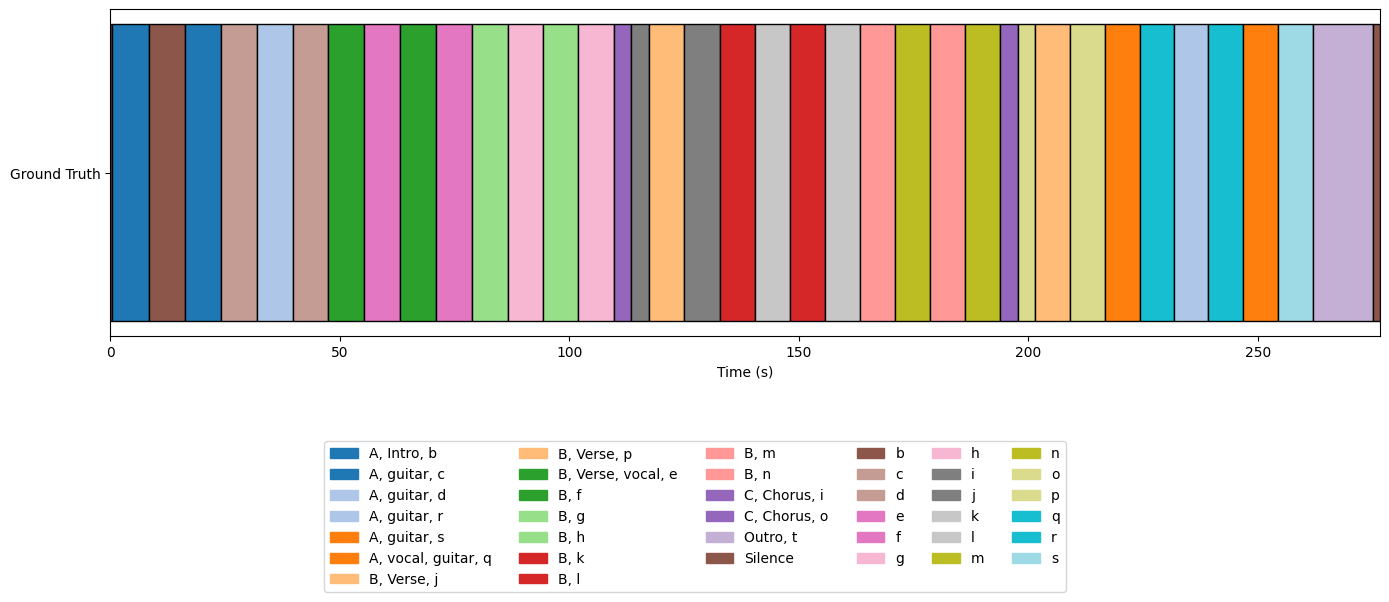

In [132]:
# Convert to string labels
gt_labels = [idx_to_label[i] for i in beat_labels]
pred_labels_str = [idx_to_label[i] for i in pred_labels_smoothed]

# Visualize with legend
visualize_comparison(beat_times, gt_labels, pred_labels_str, idx_to_label)
visualize_annotations("../spectrogram-generation/SALAMI-data/combined_data.json", salami_id=3)